<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/LST_allgemeine_Berechnungen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook entthält Vorprüfungen zur Bestimmung des Cloud Cover thresholds und LST-Werte über Stadtgebiet gemittelt für jede Szene zwischen 2019-2024





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Bibliotheken installieren und Zugriffe gewähren
import ee
import geemap
import folium
from datetime import datetime
import geopandas as gpd
from shapely.geometry import mapping
import pandas as pd
import matplotlib.pyplot as plt


ee.Authenticate()
ee.Initialize(project="ee-sarahheinz0405")


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [3]:
staedte_ueber_50tsd_polygone = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/grenzen_ueber_50tsd.gpkg")
staedte_ueber_50tsd_polygone.head()

,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,11.360777,48.061624,11.722910,48.248116,116687199,relation,62428,48.137108,11.575382,boundary,administrative,12,0.799006,city,Munich,"Munich, Bavaria, Germany","MULTIPOLYGON (((11.36078 48.15807, 11.36085 48..."
1,10.988733,49.331434,11.282596,49.540753,115962439,relation,62780,49.453872,11.077298,boundary,administrative,12,0.709195,city,Nuremberg,"Nuremberg, Bavaria, Germany","MULTIPOLYGON (((10.98873 49.53654, 10.98906 49..."
2,10.763362,48.258144,10.959333,48.458654,116219980,relation,62407,48.369034,10.897952,boundary,administrative,12,0.679385,city,Augsburg,"Augsburg, Bavaria, Germany","MULTIPOLYGON (((10.76336 48.30213, 10.76336 48..."
3,12.029075,48.966746,12.191608,49.076416,119951011,relation,62411,49.019533,12.097487,boundary,administrative,12,0.670191,city,Regensburg,"Regensburg, Bavaria, Germany","MULTIPOLYGON (((12.02907 49.01102, 12.02908 49..."
4,11.255908,48.683877,11.503422,48.822891,116627625,relation,62381,48.763016,11.425040,boundary,administrative,12,0.625744,city,Ingolstadt,"Ingolstadt, Bavaria, Germany","MULTIPOLYGON (((11.25591 48.77946, 11.25634 48..."


# Anzahl der Szenen bei unterschiedlicher Wolkenbedeckung überprüfen

Zeitraum: Juni bis August der Jahre 2019-2024

In [4]:
staedte_ueber_50tsd_polygone = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/grenzen_ueber_50tsd.gpkg")

# Anzahl der Szenen bei unterschiedlicher Wolkenbedeckung überprüfen

# Zeiträume für die Monate Juni bis August der Jahre 2019-2024
years = range(2019, 2025)  # Jahre von 2019 bis einschließlich 2024
date_ranges = [(f'{year}-06-01', f'{year}-08-31') for year in years]

# Cloud Cover-Werte
cloud_cover_values = [5, 10, 20, 30, 40, 50]

results = {}
# Loop directly through the GeoDataFrame rows
for index, row in staedte_ueber_50tsd_polygone.iterrows():
    city_name = row['name']
    geometry = row['geometry']

    # Convert the shapely geometry to an Earth Engine geometry
    region = ee.Geometry(mapping(geometry))

    results[city_name] = {}
    for cloud_cover in cloud_cover_values:
        total_scenes = 0
        # Schleife über die definierten Zeiträume
        for start_date, end_date in date_ranges:
            landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
                .filterDate(start_date, end_date) \
                .filterBounds(region) \
                .filter(ee.Filter.lt('CLOUD_COVER', cloud_cover))
            num_scenes = landsat.size().getInfo()
            total_scenes += num_scenes # Anzahl der Szenen für den aktuellen Zeitraum hinzufügen

        results[city_name][cloud_cover] = total_scenes # Gesamtzahl der Szenen für alle Zeiträume speichern

# Ergebnisse in Tabelle ausgeben
print("Gesamtanzahl der Szenen für verschiedene Cloud Cover-Werte (Juni-August, 2019-2024):")
print("Stadt\t| 5%\t| 10%\t| 20%\t| 30%\t| 40%\t| 50%")
print("-" * 80) # Trennlinie angepasst
for city_name, data in results.items():
    row = f"{city_name}\t|"
    for cloud_cover in cloud_cover_values:
        # Stellen Sie sicher, dass der Wert in der Ergebnistabelle vorhanden ist, bevor Sie ihn formatieren
        scene_count = data.get(cloud_cover, 0) # Standardwert 0, falls kein Ergebnis gefunden wurde
        row += f" {scene_count}\t|"
    print(row)

KeyboardInterrupt: 

=> 10 Prozent wählen und mittlere Pixel-LST für alle Städte in dem Zeitraum berechnen

# Durchschnitts-LST für Gesamt-Stadtgebiet für jede Szene

Wolkenmaskierung

In [6]:
def maskClouds(image):
    # QA_PIXEL-Band auswählen
    qa_band = image.select('QA_PIXEL')

    # Bitmasken für Wolkenschatten (Bit 3) und Wolken (Bit 5) definieren
    cloud_shadow_bitmask = (1 << 4)  # 00001000 = 8
    cloud_bitmask = (1 << 3)         # 00100000 = 32

    # Prüfen, ob die relevanten Bits nicht gesetzt sind (d.h. wolkenfreie Pixel)
    mask = qa_band.bitwiseAnd(cloud_shadow_bitmask).eq(0).And(
           qa_band.bitwiseAnd(cloud_bitmask).eq(0))

    # Maske auf das Bild anwenden
    return image.updateMask(mask)


In [7]:
# Funktion zur Berechnung der LST
def calculateLST(image):
    kelvin = image.select('ST_B10').multiply(0.00341802).add(149.0)  # Radiance -> Kelvin
    lst_celsius = kelvin.subtract(273.15).rename('LST_Celsius')  # Kelvin -> Celsius
    return image.addBands(lst_celsius)


In [8]:
# Durchschnitts-LST für Gesamt-Stadtgebiet für jede Szene und Jahresdurchschnitte

# Zeiträume für die Monate Juni bis August der Jahre 2019-2024
years = range(2019, 2025)  # Jahre von 2019 bis einschließlich 2024
date_ranges = [(f'{year}-06-01', f'{year}-08-31') for year in years]


# Cloud Cover-Grenzwert
cloud_cover_threshold = 10

yearly_avg_lst = {} # Dictionary zum Speichern der Jahresdurchschnitte
total_avg_lst_values = [] # Liste zum Speichern aller durchschnittlichen LST-Werte zur Berechnung des Gesamtdurchschnitts

# Loop directly through the GeoDataFrame rows
for index, row in staedte_ueber_50tsd_polygone.iterrows():
    city_name = row['name']
    geometry = row['geometry']

    # Convert the shapely geometry to an Earth Engine geometry
    region = ee.Geometry(mapping(geometry))

    print(f"\nVerarbeitung von Szenen für {city_name} (Cloud Cover < {cloud_cover_threshold}%)")

    city_lst_values = [] # Liste zum Speichern der LST-Werte für die aktuelle Stadt

    # Schleife über die definierten Zeiträume (Jun-Aug für jedes Jahr)
    for year, (start_date, end_date) in zip(years, date_ranges):
        print(f"  Zeitraum: {start_date} bis {end_date}")

        landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(region) \
            .filter(ee.Filter.lt('CLOUD_COVER', cloud_cover_threshold)) \
            .map(maskClouds) \
            .map(calculateLST)

        # Anzahl der gefundenen Szenen
        num_scenes_in_period = landsat.size().getInfo()
        print(f"    Anzahl der gefundenen Szenen: {num_scenes_in_period}")

        # Nur fortfahren, wenn Szenen gefunden wurden
        if num_scenes_in_period > 0:
            # Schleife über jede Szene im Zeitraum
            for image_index in range(num_scenes_in_period):
                image = ee.Image(landsat.toList(num_scenes_in_period).get(image_index))

                # Datum der Szene extrahieren
                scene_date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd').getInfo()

                # Durchschnittliche LST über das Stadtgebiet berechnen
                avg_lst_image = image.select('LST_Celsius').reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=region,
                    scale=30 # Auflösung in Metern
                )

                # Den Wert extrahieren und prüfen, ob er vorhanden ist
                avg_lst_value = avg_lst_image.get('LST_Celsius').getInfo()

                if avg_lst_value is not None:
                    print(f"    Szene vom {scene_date}: Durchschnittliche LST = {avg_lst_value:.2f} °C")
                    city_lst_values.append(avg_lst_value)
                    total_avg_lst_values.append(avg_lst_value) # LST-Wert zum Gesamtdurchschnitt hinzufügen

        # Berechnung des Jahresdurchschnitts, wenn Szenen vorhanden waren
        if city_lst_values:
            if year not in yearly_avg_lst:
                yearly_avg_lst[year] = {}
            if city_name not in yearly_avg_lst[year]:
                yearly_avg_lst[year][city_name] = []
            yearly_avg_lst[year][city_name].extend(city_lst_values)
            city_lst_values = [] # Liste für die Stadt für den nächsten Zeitraum zurücksetzen


# Berechnung und Ausgabe der Jahresdurchschnitte
print("\nJahresdurchschnitte der LST für jede Stadt (Juni-August, 2019-2024):")
print("Stadt\t| 2019\t| 2020\t| 2021\t| 2022\t| 2023\t| 2024")
print("-" * 80)
for index, row in staedte_ueber_50tsd_polygone.iterrows():
    city_name = row['name']
    row_output = f"{city_name}\t|"
    for year in years:
        if year in yearly_avg_lst and city_name in yearly_avg_lst[year] and yearly_avg_lst[year][city_name]:
            avg_for_year_city = sum(yearly_avg_lst[year][city_name]) / len(yearly_avg_lst[year][city_name])
            row_output += f" {avg_for_year_city:.2f}\t|"
        else:
            row_output += f" ---\t|" # Zeigt "---" an, wenn keine Daten für das Jahr/die Stadt vorhanden sind
    print(row_output)


# Berechnung und Ausgabe des Gesamtdurchschnitts aller Szenen
if total_avg_lst_values:
    overall_avg_lst = sum(total_avg_lst_values) / len(total_avg_lst_values)
    print(f"\nGesamtdurchschnittliche LST über alle Städte und Jahre (Juni-August, 2019-2024): {overall_avg_lst:.2f} °C")
else:
    print("\nKeine LST-Daten gefunden, um den Gesamtdurchschnitt zu berechnen.")


Verarbeitung von Szenen für Munich (Cloud Cover < 10%)
  Zeitraum: 2019-06-01 bis 2019-08-31
    Anzahl der gefundenen Szenen: 6
    Szene vom 2019-06-24: Durchschnittliche LST = 30.52 °C
    Szene vom 2019-07-26: Durchschnittliche LST = 39.83 °C
    Szene vom 2019-08-11: Durchschnittliche LST = 31.98 °C
    Szene vom 2019-08-27: Durchschnittliche LST = 31.89 °C
    Szene vom 2019-06-24: Durchschnittliche LST = 30.44 °C
    Szene vom 2019-08-27: Durchschnittliche LST = 31.86 °C
  Zeitraum: 2020-06-01 bis 2020-08-31
    Anzahl der gefundenen Szenen: 4
    Szene vom 2020-08-06: Durchschnittliche LST = 29.21 °C
    Szene vom 2020-06-26: Durchschnittliche LST = 32.77 °C
    Szene vom 2020-07-28: Durchschnittliche LST = 37.01 °C
    Szene vom 2020-07-28: Durchschnittliche LST = 36.98 °C
  Zeitraum: 2021-06-01 bis 2021-08-31
    Anzahl der gefundenen Szenen: 1
    Szene vom 2021-06-13: Durchschnittliche LST = 30.44 °C
  Zeitraum: 2022-06-01 bis 2022-08-31
    Anzahl der gefundenen Szenen: 6

In [11]:
# Erstellen Sie eine Tabelle (DataFrame) aus den Jahresdurchschnittswerten
yearly_avg_lst_df = pd.DataFrame(yearly_avg_lst)

# Stellen Sie sicher, dass alle Städte im DataFrame vorhanden sind, auch wenn sie keine Daten für alle Jahre haben
all_cities = staedte_ueber_50tsd_polygone['name'].tolist()
yearly_avg_lst_df = yearly_avg_lst_df.reindex(index=all_cities)

# Benennen Sie die Spalten um, um die Jahre widerzuspiegeln
yearly_avg_lst_df.columns = years

# Berechnen Sie den Durchschnitt der Listen in jeder Zelle
yearly_avg_lst_df = yearly_avg_lst_df.map(lambda x: sum(x) / len(x) if isinstance(x, list) and len(x) > 0 else None)


# Benennen Sie den Index nach Städtenamen
yearly_avg_lst_df.index.name = 'Stadt'

# Geben Sie die Tabelle aus
print("\nJahresdurchschnitte der LST für jede Stadt (Juni-August, 2019-2024):")
display(yearly_avg_lst_df)


Jahresdurchschnitte der LST für jede Stadt (Juni-August, 2019-2024):


,2019,2020,2021,2022,2023,2024
Stadt,,,,,,
Munich,32.751570,33.993656,30.442737,34.010296,37.663199,31.874179
Nuremberg,35.843888,34.448124,31.999048,38.090691,36.973569,33.402390
Augsburg,32.158765,32.588483,29.990438,33.678144,35.772660,32.697173
Regensburg,35.001246,33.733329,28.755014,33.379937,37.280987,35.012789
Ingolstadt,32.463429,31.845072,28.250693,35.828923,38.458047,32.967189
Würzburg,37.324277,31.868036,30.517961,41.193688,24.956447,22.895665
Fürth,36.035411,34.903426,31.886053,38.054587,36.998949,32.566341
Erlangen,37.076836,31.989312,31.393946,36.496509,30.368955,34.207867
Bamberg,36.363542,31.304009,25.592617,34.607089,31.907449,30.561570


# Plots für durchschnittliche LST in allen Städten und Zeiträumen

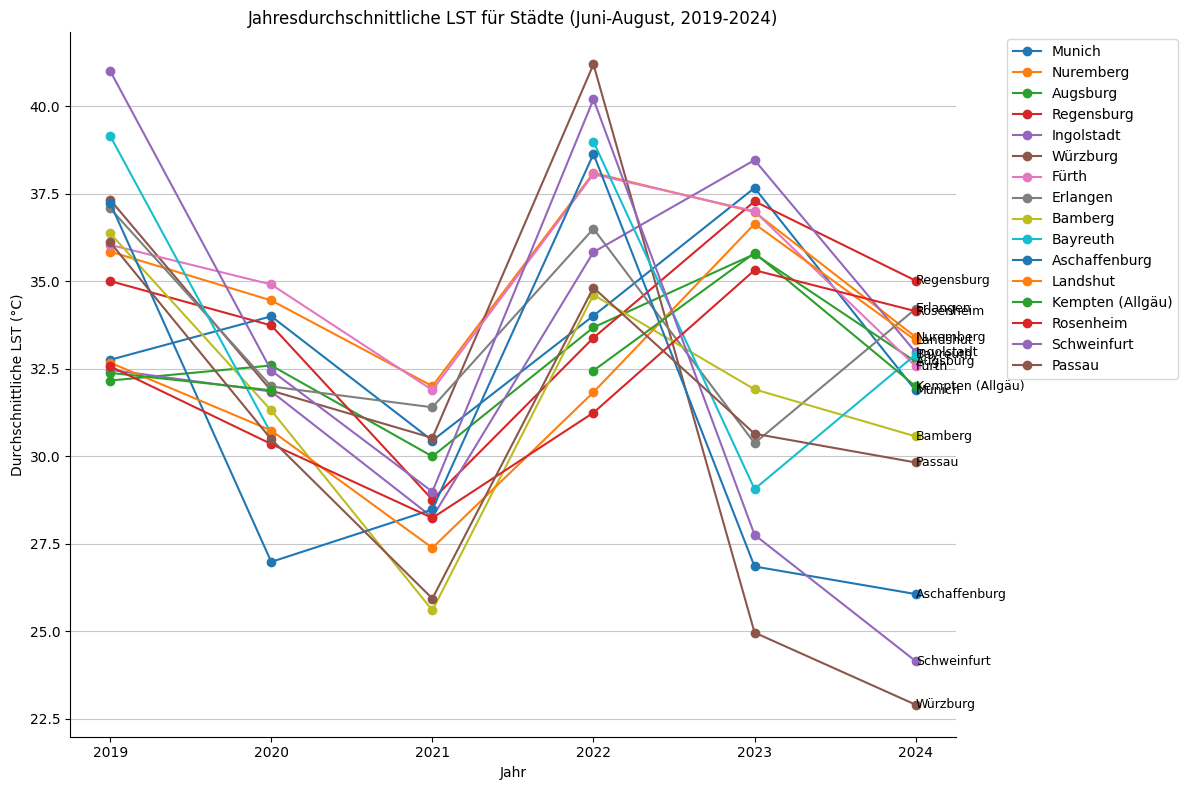

In [14]:
import matplotlib.pyplot as plt

# Transponieren Sie das DataFrame, damit die Jahre auf der X-Achse liegen
yearly_avg_lst_df_T = yearly_avg_lst_df.T

plt.figure(figsize=(12, 8))
ax = plt.gca() # Get the current axes

# Plotten Sie jede Stadt als separate Linie
for city in yearly_avg_lst_df_T.columns:
    plt.plot(yearly_avg_lst_df_T.index, yearly_avg_lst_df_T[city], marker='o', linestyle='-', label=city)

# Beschriftungen und Titel
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche LST (°C)')
plt.title('Jahresdurchschnittliche LST für Städte (Juni-August, 2019-2024)')
# plt.grid(True) # Entfernen Sie die Standard-Gitterlinien

# Entfernen Sie den oberen und rechten Rahmen
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Fügen Sie nur horizontale Gitterlinien hinzu
ax.yaxis.grid(True, linestyle='-', alpha=0.7)
ax.xaxis.grid(False) # Stellen Sie sicher, dass vertikale Gitterlinien ausgeschaltet sind


# Beschriftung am Ende jeder Linie (optional, kann bei vielen Linien unübersichtlich werden)
# Sie können stattdessen eine Legende verwenden, wie oben implementiert.
# Wenn Sie die Legende entfernen und nur die Endbeschriftungen möchten, entfernen Sie 'label=city' in plt.plot()
# und fügen Sie den folgenden Code hinzu:
for city in yearly_avg_lst_df_T.columns:
     last_year = yearly_avg_lst_df_T.index[-1]
     last_lst = yearly_avg_lst_df_T[city].dropna().iloc[-1] # Handle potential NaN at the end
     plt.text(last_year, last_lst, city, fontsize=9, verticalalignment='center')


# Legende außerhalb des Plots platzieren
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Verhindert Überschneidungen von Elementen
plt.show()

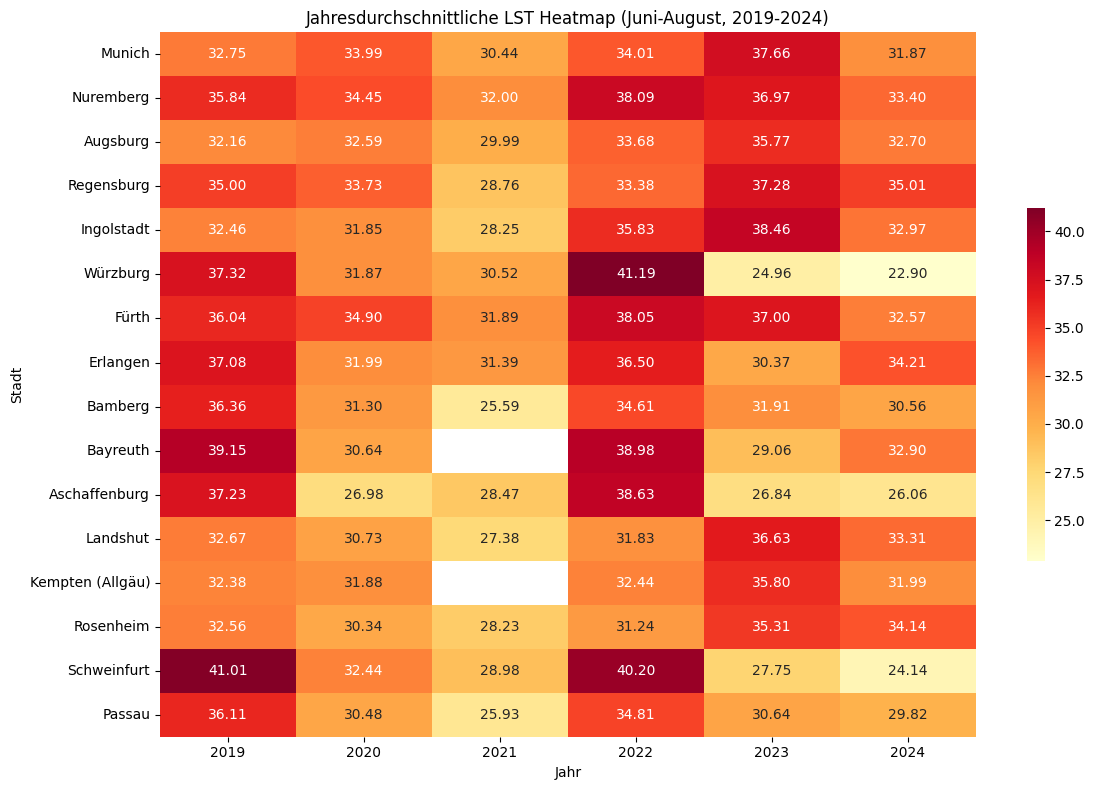

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Anpassen der Farbskala (Legende)
# shrink: Größe der Farbskala (z.B. 0.5 für die Hälfte der Höhe)
# aspect: Verhältnis von Höhe zu Breite der Farbskala
# location: Position der Farbskala ('upper right', 'upper left', 'lower right', 'lower left', 'right', 'left', 'top', 'bottom')
cbar_kws = {"shrink": 0.5, "aspect": 20, "location": "right"}


sns.heatmap(yearly_avg_lst_df, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws=cbar_kws)

plt.title('Jahresdurchschnittliche LST Heatmap (Juni-August, 2019-2024)')
plt.xlabel('Jahr')
plt.ylabel('Stadt')
plt.tight_layout()
plt.show()

In [24]:
# Berechnen Sie den Durchschnitt über alle Jahre für jede Stadt
six_year_avg_lst = yearly_avg_lst_df.mean(axis=1)

# Sortieren Sie die Städte basierend auf dem Sechs-Jahres-Durchschnitt in absteigender Reihenfolge
ranked_cities = six_year_avg_lst.sort_values(ascending=False)

# Geben Sie die Rangliste aus
print("Rangliste der Städte basierend auf der durchschnittlichen Sommer-LST (2019-2024):")
print(ranked_cities)

Rangliste der Städte basierend auf der durchschnittlichen Sommer-LST (2019-2024):
Stadt
Nuremberg           35.126285
Fürth               35.074128
Bayreuth            34.146083
Regensburg          33.860550
Erlangen            33.588904
Munich              33.455939
Ingolstadt          33.302225
Kempten (Allgäu)    32.899354
Augsburg            32.814277
Schweinfurt         32.419281
Landshut            32.090349
Rosenheim           31.972209
Bamberg             31.722713
Würzburg            31.459346
Passau              31.297400
Aschaffenburg       30.703038
dtype: float64


Durchschnitt nochmal basierend auf allen Szenen berechnen

=> damit wird jede Szene gleich viel gewertet und geht nicht im Jahresdurchschnitt unter

In [26]:
# Berechnung des Durchschnitts-LST für Gesamt-Stadtgebiet basierend auf allen Szenen

# Zeiträume für die Monate Juni bis August der Jahre 2019-2024
years = range(2019, 2025)  # Jahre von 2019 bis einschließlich 2024
date_ranges = [(f'{year}-06-01', f'{year}-08-31') for year in years]


# Cloud Cover-Grenzwert
cloud_cover_threshold = 10

# Dictionary zum Speichern aller LST-Werte für jede Stadt über den gesamten Zeitraum
city_all_lst_values_all_scenes = {city_name: [] for city_name in staedte_ueber_50tsd_polygone['name'].tolist()}

# Loop directly through the GeoDataFrame rows
for index, row in staedte_ueber_50tsd_polygone.iterrows():
    city_name = row['name']
    geometry = row['geometry']

    # Convert the shapely geometry to an Earth Engine geometry
    region = ee.Geometry(mapping(geometry))

    print(f"\nVerarbeitung aller Szenen für {city_name} (Cloud Cover < {cloud_cover_threshold}%)")

    # Schleife über die definierten Zeiträume (Jun-Aug für jedes Jahr)
    for year, (start_date, end_date) in zip(years, date_ranges):
        # print(f"  Zeitraum: {start_date} bis {end_date}") # Optional: zum Debuggen

        landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(region) \
            .filter(ee.Filter.lt('CLOUD_COVER', cloud_cover_threshold)) \
            .map(maskClouds) \
            .map(calculateLST)

        # Überprüfen Sie die Anzahl der gefundenen Szenen, bevor Sie .toList() aufrufen
        num_scenes_in_period = landsat.size().getInfo()
        # print(f"    Anzahl der gefundenen Szenen in {year}: {num_scenes_in_period}")


        if num_scenes_in_period > 0:
            # Schleife über jede Szene im Zeitraum und Extraktion der LST
            landsat_list = landsat.toList(num_scenes_in_period) # Holen Sie die Liste der Bilder

            for image_index in range(num_scenes_in_period):
                image = ee.Image(landsat_list.get(image_index))

                # Durchschnittliche LST über das Stadtgebiet berechnen
                avg_lst_image = image.select('LST_Celsius').reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=region,
                    scale=30 # Auflösung in Metern
                )

                # Den Wert extrahieren und prüfen, ob er vorhanden ist
                avg_lst_value = avg_lst_image.get('LST_Celsius').getInfo()

                if avg_lst_value is not None:
                    city_all_lst_values_all_scenes[city_name].append(avg_lst_value)


# Berechnung und Ausgabe des Gesamtdurchschnitts für jede Stadt basierend auf allen Szenen
print("\nGesamtdurchschnittliche LST für jede Stadt (Juni-August, 2019-2024) basierend auf allen Szenen:")
print("Stadt\t| Durchschnittliche LST (°C)")
print("-" * 60)
overall_avg_lst_per_city_all_scenes = {}
for city_name, lst_values in city_all_lst_values_all_scenes.items():
    if lst_values:
        overall_avg = sum(lst_values) / len(lst_values)
        overall_avg_lst_per_city_all_scenes[city_name] = overall_avg
        print(f"{city_name}\t| {overall_avg:.2f}")
    else:
        overall_avg_lst_per_city_all_scenes[city_name] = None # Keine Daten für diese Stadt
        print(f"{city_name}\t| ---")

# Optional: Erstellen Sie eine Rangliste basierend auf diesem neuen Durchschnitt
print("\nRangliste der Städte basierend auf der durchschnittlichen Sommer-LST (basierend auf allen Szenen):")
ranked_cities_all_scenes = pd.Series(overall_avg_lst_per_city_all_scenes).sort_values(ascending=False)
print(ranked_cities_all_scenes)


Verarbeitung aller Szenen für Munich (Cloud Cover < 10%)

Verarbeitung aller Szenen für Nuremberg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Augsburg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Regensburg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Ingolstadt (Cloud Cover < 10%)

Verarbeitung aller Szenen für Würzburg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Fürth (Cloud Cover < 10%)

Verarbeitung aller Szenen für Erlangen (Cloud Cover < 10%)

Verarbeitung aller Szenen für Bamberg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Bayreuth (Cloud Cover < 10%)

Verarbeitung aller Szenen für Aschaffenburg (Cloud Cover < 10%)

Verarbeitung aller Szenen für Landshut (Cloud Cover < 10%)

Verarbeitung aller Szenen für Kempten (Allgäu) (Cloud Cover < 10%)

Verarbeitung aller Szenen für Rosenheim (Cloud Cover < 10%)

Verarbeitung aller Szenen für Schweinfurt (Cloud Cover < 10%)

Verarbeitung aller Szenen für Passau (Cloud Cover < 10%)

Gesamtdurchschnittliche L

In [28]:
# Konvertieren Sie die Rangliste in ein DataFrame für die Ausgabe
ranked_cities_df = ranked_cities_all_scenes.reset_index()
ranked_cities_df.columns = ['Stadt', 'Durchschnittliche Sommer-LST (°C)']

# Runden Sie die LST-Daten auf 2 Nachkommastellen
ranked_cities_df['Durchschnittliche Sommer-LST (°C)'] = ranked_cities_df['Durchschnittliche Sommer-LST (°C)'].round(2)


# Speichern Sie die Tabelle als CSV-Datei
output_csv_path = '/content/ranked_cities_all_scenes.csv'
ranked_cities_df.to_csv(output_csv_path, index=False)

print(f"Die Rangliste wurde als '{output_csv_path}' gespeichert.")
display(ranked_cities_df)

Die Rangliste wurde als '/content/ranked_cities_all_scenes.csv' gespeichert.


,Stadt,Durchschnittliche Sommer-LST (°C)
0,Fürth,35.58
1,Nuremberg,35.54
2,Bayreuth,35.22
3,Erlangen,34.69
4,Regensburg,34.31
5,Munich,33.72
6,Bamberg,33.42
7,Ingolstadt,33.07
8,Augsburg,32.84
9,Kempten (Allgäu),32.45
